In [1]:
# Import required libraries
import mne
import numpy as np
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
import warnings

# Suppress warnings for cleaner output
mne.set_log_level('WARNING')
warnings.filterwarnings('ignore')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Set dataset path
dataset_path = Path('/home/alookaladdoo/DPCN-Project/Dataset')

# Get list of all subjects
subjects = sorted([d for d in os.listdir(dataset_path) if d.startswith('sub-NORB')])
print(f"Found {len(subjects)} total subjects")

Found 103 total subjects


In [3]:
# Find subjects with multiple sessions
def get_sessions_per_subject(dataset_path, subjects):
    """
    Get the number of sessions for each subject.
    
    Returns:
    --------
    dict : {subject_id: [list of session EDFs]}
    """
    subject_sessions = {}
    
    for subject in subjects:
        subject_path = dataset_path / subject
        if subject_path.exists():
            # Find all EDF files
            edf_files = sorted(list(subject_path.rglob('*.edf')))
            
            if len(edf_files) > 0:
                subject_sessions[subject] = edf_files
    
    return subject_sessions

# Get all sessions
all_sessions = get_sessions_per_subject(dataset_path, subjects)

# Filter for subjects with multiple sessions
multi_session_subjects = {subj: files for subj, files in all_sessions.items() if len(files) > 1}

print(f"\n📊 Session Statistics:")
print(f"  Total subjects: {len(all_sessions)}")
print(f"  Subjects with multiple sessions: {len(multi_session_subjects)}")

# Show session distribution
session_counts = [len(files) for files in all_sessions.values()]
print(f"\n📈 Session Distribution:")
print(f"  Min sessions: {min(session_counts)}")
print(f"  Max sessions: {max(session_counts)}")
print(f"  Mean sessions: {np.mean(session_counts):.2f}")

# Show subjects with most sessions
print(f"\n🔝 Subjects with most sessions:")
sorted_subjects = sorted(multi_session_subjects.items(), key=lambda x: len(x[1]), reverse=True)
for subj, files in sorted_subjects[:5]:
    print(f"  {subj}: {len(files)} sessions")


📊 Session Statistics:
  Total subjects: 103
  Subjects with multiple sessions: 22

📈 Session Distribution:
  Min sessions: 1
  Max sessions: 4
  Mean sessions: 1.26

🔝 Subjects with most sessions:
  sub-NORB00069: 4 sessions
  sub-NORB00064: 3 sessions
  sub-NORB00070: 3 sessions
  sub-NORB00075: 3 sessions
  sub-NORB00065: 2 sessions


In [4]:
# Helper functions from granger-causality-analysis-minimal.ipynb

def detect_bad_channels(raw, flat_threshold=1e-12, noise_threshold=1e-3, verbose=False):
    """Detect bad channels (flat or extremely noisy)."""
    data = raw.get_data()
    channel_names = raw.ch_names
    bad_channels = []
    
    for i, ch_name in enumerate(channel_names):
        ch_data = data[i, :]
        ch_std = np.std(ch_data)
        
        is_bad = False
        
        # Check if flat, noisy, or reference/ground
        if ch_std < flat_threshold or ch_std > noise_threshold:
            is_bad = True
        
        if ch_name.upper() in ['PG1', 'PG2', 'REF', 'GND', 'GROUND', '25+', '26+', '27+']:
            is_bad = True
        
        if is_bad:
            bad_channels.append(ch_name)
    
    if verbose:
        print(f"  Bad channels: {len(bad_channels)}/{len(channel_names)}")
    
    return bad_channels


def normalize_segments(segments):
    """Standardize each segment by z-scoring each channel."""
    normalized_segments = []
    
    for segment in segments:
        mean = segment.mean(axis=1, keepdims=True)
        std = segment.std(axis=1, keepdims=True)
        std[std == 0] = 1
        normalized_segment = (segment - mean) / std
        normalized_segments.append(normalized_segment)
    
    return normalized_segments


def select_model_order(segment, max_order=20):
    """Select optimal VAR model order using BIC."""
    model = VAR(segment.T)
    bic_values = {}
    for order in range(1, max_order + 1):
        try:
            bic_values[order] = model.fit(order, verbose=False).bic
        except:
            continue
    return min(bic_values, key=bic_values.get) if bic_values else 1


def compute_gc_matrix(var_model, n_channels):
    """Compute GC matrix from fitted VAR model."""
    gc_matrix = np.zeros((n_channels, n_channels))
    for i in range(n_channels):
        for j in range(n_channels):
            if i != j:
                try:
                    gc_result = var_model.test_causality(i, j, kind='f')
                    gc_matrix[j, i] = -np.log(gc_result.pvalue + 1e-10)
                except:
                    gc_matrix[j, i] = 0
    return gc_matrix

print("✓ Helper functions defined")

✓ Helper functions defined


In [5]:
# Process a single session
def process_single_session(edf_path, window_length=10.0, overlap=0.5, fixed_order=None, verbose=False):
    """
    Process a single EDF session and compute GC matrix.
    
    Parameters:
    -----------
    edf_path : Path
        Path to EDF file
    window_length : float
        Window length in seconds
    overlap : float
        Overlap fraction (0.0 to 1.0)
    fixed_order : int or None
        Fixed VAR order (if None, will use BIC selection)
    verbose : bool
        Print progress information
        
    Returns:
    --------
    dict : {
        'gc_matrix': averaged GC matrix,
        'n_channels': number of channels,
        'n_windows': number of windows,
        'order': VAR model order,
        'channel_names': list of channel names,
        'duration': recording duration in seconds
    }
    """
    try:
        if verbose:
            print(f"  Loading: {edf_path.name}")
        
        # Load data
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
        duration = raw.times[-1]
        
        # Detect and remove bad channels
        bad_channels = detect_bad_channels(raw, verbose=verbose)
        if bad_channels:
            raw.drop_channels(bad_channels)
        
        # Skip if too few channels
        if len(raw.ch_names) < 2:
            if verbose:
                print(f"  ⚠ Skipped: too few channels ({len(raw.ch_names)})")
            return None
        
        # Bandpass filter
        raw.filter(l_freq=0.5, h_freq=30.0, fir_design='firwin', verbose=False)
        
        # Segment data
        sfreq = raw.info['sfreq']
        data_filtered = raw.get_data()
        n_channels, n_samples = data_filtered.shape
        samples_per_window = int(window_length * sfreq)
        step_size = int(samples_per_window * (1 - overlap))
        
        segments = []
        start = 0
        while start + samples_per_window <= n_samples:
            segment = data_filtered[:, start:start + samples_per_window]
            segments.append(segment)
            start += step_size
        
        if len(segments) < 1:
            if verbose:
                print(f"  ⚠ Skipped: no valid segments")
            return None
        
        # Normalize segments
        segments_normalized = normalize_segments(segments)
        
        # Select model order
        if fixed_order is None:
            order = select_model_order(segments_normalized[0], max_order=10)
        else:
            order = fixed_order
        
        # Fit VAR models
        var_models = []
        for segment in segments_normalized:
            model = VAR(segment.T)
            var_models.append(model.fit(order, verbose=False))
        
        # Compute GC matrices
        gc_matrices = [compute_gc_matrix(model, n_channels) for model in var_models]
        
        # Average across windows
        gc_avg = np.mean(gc_matrices, axis=0)
        
        if verbose:
            print(f"  ✓ Processed: {n_channels} channels, {len(segments)} windows, order {order}")
        
        return {
            'gc_matrix': gc_avg,
            'n_channels': n_channels,
            'n_windows': len(segments),
            'order': order,
            'channel_names': raw.ch_names,
            'duration': duration
        }
        
    except Exception as e:
        if verbose:
            print(f"  ✗ Error: {str(e)}")
        return None

print("✓ Session processing function defined")

✓ Session processing function defined


In [6]:
# Process all multi-session subjects
session_results = {}

print(f"Processing {len(multi_session_subjects)} subjects with multiple sessions...")
print("=" * 70)

for idx, (subject_id, edf_files) in enumerate(multi_session_subjects.items(), 1):
    print(f"\n[{idx}/{len(multi_session_subjects)}] {subject_id} ({len(edf_files)} sessions)")
    
    subject_data = []
    
    for session_idx, edf_file in enumerate(sorted(edf_files), 1):
        # Extract session ID from filename
        session_name = edf_file.stem.split('_')[1] if '_' in edf_file.stem else f'ses-{session_idx:02d}'
        
        print(f"  Session {session_idx}/{len(edf_files)}: {session_name}")
        
        # Process session
        result = process_single_session(edf_file, fixed_order=2, verbose=True)
        
        if result is not None:
            result['session_id'] = session_name
            result['edf_file'] = edf_file.name
            subject_data.append(result)
    
    if len(subject_data) > 0:
        session_results[subject_id] = subject_data
        print(f"  ✓ Successfully processed {len(subject_data)}/{len(edf_files)} sessions")
    else:
        print(f"  ✗ No valid sessions")

print("\n" + "=" * 70)
print(f"✓ Processing complete!")
print(f"  Subjects with valid sessions: {len(session_results)}")
print(f"  Total sessions processed: {sum(len(data) for data in session_results.values())}")

Processing 22 subjects with multiple sessions...

[1/22] sub-NORB00064 (3 sessions)
  Session 1/3: ses-1
  Loading: sub-NORB00064_ses-1_task-EEG_eeg.edf
  Bad channels: 0/19
  ✓ Processed: 19 channels, 63 windows, order 2
  Session 2/3: ses-2
  Loading: sub-NORB00064_ses-2_task-EEG_eeg.edf
  Bad channels: 0/19
  ✓ Processed: 19 channels, 71 windows, order 2
  Session 3/3: ses-3
  Loading: sub-NORB00064_ses-3_task-EEG_eeg.edf
  Bad channels: 0/19
  ✓ Processed: 19 channels, 64 windows, order 2
  ✓ Successfully processed 3/3 sessions

[2/22] sub-NORB00065 (2 sessions)
  Session 1/2: ses-1
  Loading: sub-NORB00065_ses-1_task-EEG_eeg.edf
  Bad channels: 0/19
  ✓ Processed: 19 channels, 64 windows, order 2
  Session 2/2: ses-2
  Loading: sub-NORB00065_ses-2_task-EEG_eeg.edf
  Bad channels: 0/19
  ✓ Processed: 19 channels, 63 windows, order 2
  ✓ Successfully processed 2/2 sessions

[3/22] sub-NORB00069 (4 sessions)
  Session 1/4: ses-1
  Loading: sub-NORB00069_ses-1_task-EEG_eeg.edf
  Bad c

In [7]:
# Create summary dataframe
summary_data = []

for subject_id, sessions in session_results.items():
    for session_data in sessions:
        gc_matrix = session_data['gc_matrix']
        
        summary_data.append({
            'Subject': subject_id,
            'Session': session_data['session_id'],
            'N_Channels': session_data['n_channels'],
            'N_Windows': session_data['n_windows'],
            'VAR_Order': session_data['order'],
            'Duration_sec': session_data['duration'],
            'Mean_GC': gc_matrix.mean(),
            'Max_GC': gc_matrix.max(),
            'Std_GC': gc_matrix.std()
        })

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.sort_values(['Subject', 'Session'])

print("Session-Wise Summary:")
print(df_summary.to_string(index=False))

# Save summary
output_dir = Path('/home/alookaladdoo/DPCN-Project/results')
output_dir.mkdir(exist_ok=True)
df_summary.to_csv(output_dir / 'session_wise_summary.csv', index=False)
print(f"\n✓ Saved summary to: {output_dir / 'session_wise_summary.csv'}")

Session-Wise Summary:
      Subject Session  N_Channels  N_Windows  VAR_Order  Duration_sec  Mean_GC    Max_GC   Std_GC
sub-NORB00064   ses-1          19         63          2       319.995 6.380797 22.708048 4.604867
sub-NORB00064   ses-2          19         71          2       359.995 4.361263 21.376577 3.149523
sub-NORB00064   ses-3          19         64          2       327.995 4.644796 20.652334 2.561465
sub-NORB00065   ses-1          19         64          2       327.995 7.796954 23.025851 6.521278
sub-NORB00065   ses-2          19         63          2       319.995 5.324401 22.970384 4.115407
sub-NORB00069   ses-1           2         72          2       367.995 3.492542  7.241881 3.497260
sub-NORB00069   ses-2          19         58          2       295.995 6.732452 23.024208 5.692388
sub-NORB00069   ses-3          19         66          2       335.995 5.981475 23.025851 5.120371
sub-NORB00069   ses-4          19         66          2       335.995 5.346661 20.602146 2.74779

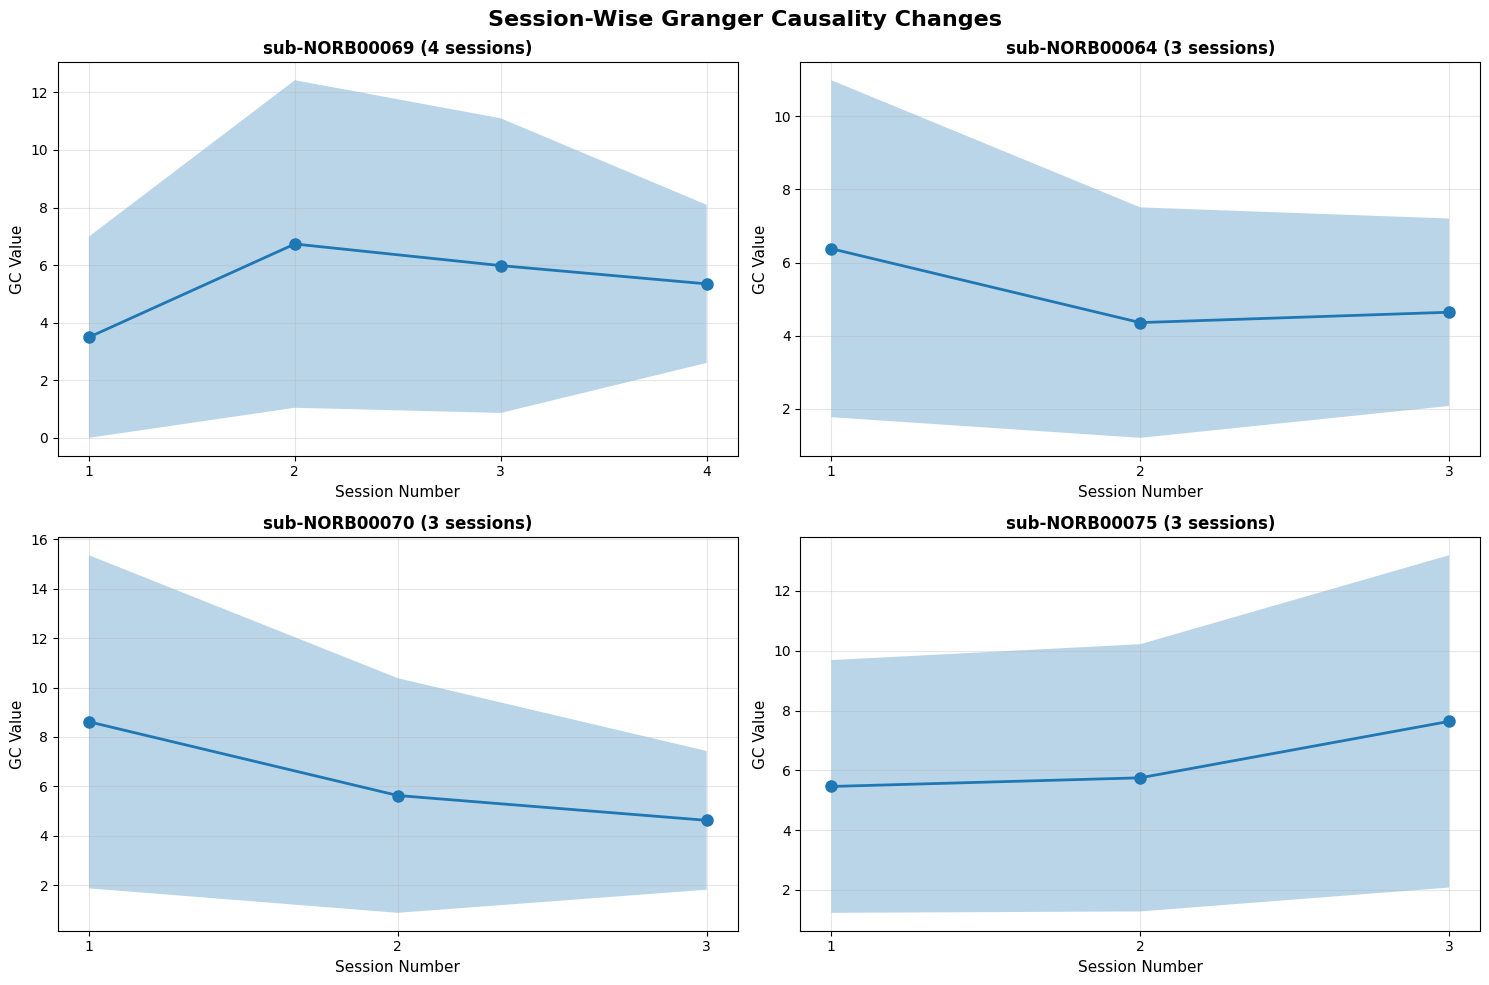

✓ Saved plot to: /home/alookaladdoo/DPCN-Project/results/session_wise_changes.png


In [8]:
# Visualize session-wise changes
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Session-Wise Granger Causality Changes', fontsize=16, fontweight='bold')

# Select subjects with most sessions for plotting
top_subjects = df_summary.groupby('Subject').size().nlargest(4).index.tolist()

for ax, subject_id in zip(axes.flat, top_subjects):
    subject_df = df_summary[df_summary['Subject'] == subject_id]
    
    sessions = range(1, len(subject_df) + 1)
    
    ax.plot(sessions, subject_df['Mean_GC'].values, 'o-', label='Mean GC', linewidth=2, markersize=8)
    ax.fill_between(sessions, 
                     subject_df['Mean_GC'].values - subject_df['Std_GC'].values,
                     subject_df['Mean_GC'].values + subject_df['Std_GC'].values,
                     alpha=0.3)
    
    ax.set_xlabel('Session Number', fontsize=11)
    ax.set_ylabel('GC Value', fontsize=11)
    ax.set_title(f'{subject_id} ({len(subject_df)} sessions)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(sessions)

plt.tight_layout()
plt.savefig(output_dir / 'session_wise_changes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved plot to: {output_dir / 'session_wise_changes.png'}")

In [9]:
# Statistical analysis of session effects
print("=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)

# Overall statistics
print(f"\n📊 Overall Statistics:")
print(f"  Subjects analyzed: {len(session_results)}")
print(f"  Total sessions: {len(df_summary)}")
print(f"  Sessions per subject: {df_summary.groupby('Subject').size().mean():.2f} ± {df_summary.groupby('Subject').size().std():.2f}")

# GC changes across sessions
print(f"\n📈 GC Value Distribution:")
print(f"  Mean GC across all sessions: {df_summary['Mean_GC'].mean():.4f} ± {df_summary['Mean_GC'].std():.4f}")
print(f"  Min Mean GC: {df_summary['Mean_GC'].min():.4f}")
print(f"  Max Mean GC: {df_summary['Mean_GC'].max():.4f}")

# Within-subject variability
print(f"\n🔄 Within-Subject Variability:")
for subject_id in df_summary['Subject'].unique():
    subject_df = df_summary[df_summary['Subject'] == subject_id]
    if len(subject_df) > 1:
        gc_change = subject_df['Mean_GC'].values[-1] - subject_df['Mean_GC'].values[0]
        gc_std = subject_df['Mean_GC'].std()
        print(f"  {subject_id}:")
        print(f"    Sessions: {len(subject_df)}")
        print(f"    GC change (last - first): {gc_change:+.4f}")
        print(f"    GC std across sessions: {gc_std:.4f}")

print("\n" + "=" * 70)

STATISTICAL SUMMARY

📊 Overall Statistics:
  Subjects analyzed: 22
  Total sessions: 49
  Sessions per subject: 2.23 ± 0.53

📈 GC Value Distribution:
  Mean GC across all sessions: 6.3379 ± 1.5730
  Min Mean GC: 3.4925
  Max Mean GC: 9.8547

🔄 Within-Subject Variability:
  sub-NORB00064:
    Sessions: 3
    GC change (last - first): -1.7360
    GC std across sessions: 1.0934
  sub-NORB00065:
    Sessions: 2
    GC change (last - first): -2.4726
    GC std across sessions: 1.7484
  sub-NORB00069:
    Sessions: 4
    GC change (last - first): +1.8541
    GC std across sessions: 1.3849
  sub-NORB00070:
    Sessions: 3
    GC change (last - first): -3.9923
    GC std across sessions: 2.0764
  sub-NORB00074:
    Sessions: 2
    GC change (last - first): -0.9296
    GC std across sessions: 0.6573
  sub-NORB00075:
    Sessions: 3
    GC change (last - first): +2.1774
    GC std across sessions: 1.1824
  sub-NORB00077:
    Sessions: 2
    GC change (last - first): +0.0485
    GC std across ses

## Channel-Wise Session Analysis

Analyze how specific channel connections change across sessions.

In [10]:
# Extract channel-wise GC values across sessions
def analyze_channel_connections(session_results):
    """
    Analyze how each channel connection changes across sessions.
    
    Returns:
    --------
    dict : {subject_id: {(source_ch, target_ch): [gc_values_per_session]}}
    """
    channel_analysis = {}
    
    for subject_id, sessions in session_results.items():
        if len(sessions) < 2:
            continue  # Skip subjects with single session
        
        # Get channel names from first session
        channel_names = sessions[0]['channel_names']
        n_channels = len(channel_names)
        
        # Initialize dictionary for this subject
        subject_connections = {}
        
        # For each channel pair
        for i in range(n_channels):
            for j in range(n_channels):
                if i != j:  # Exclude self-connections
                    connection = (channel_names[j], channel_names[i])  # (source, target)
                    gc_values = []
                    
                    # Extract GC value for this connection from each session
                    for session in sessions:
                        gc_matrix = session['gc_matrix']
                        gc_values.append(gc_matrix[i, j])
                    
                    subject_connections[connection] = gc_values
        
        channel_analysis[subject_id] = subject_connections
    
    return channel_analysis

# Perform channel-wise analysis
channel_analysis = analyze_channel_connections(session_results)

print(f"✓ Analyzed channel connections for {len(channel_analysis)} subjects")
print(f"  Example: {list(channel_analysis.keys())[0]} has {len(channel_analysis[list(channel_analysis.keys())[0]])} channel pairs")

✓ Analyzed channel connections for 22 subjects
  Example: sub-NORB00064 has 342 channel pairs


In [11]:
# Find connections with largest changes across sessions
def find_top_changing_connections(channel_analysis, top_n=10):
    """
    Find channel connections with the largest changes across sessions.
    
    Returns:
    --------
    list : [(subject, connection, change, std), ...]
    """
    changes = []
    
    for subject_id, connections in channel_analysis.items():
        for connection, gc_values in connections.items():
            if len(gc_values) > 1:
                # Calculate change (last - first) and std
                change = gc_values[-1] - gc_values[0]
                std = np.std(gc_values)
                
                changes.append({
                    'Subject': subject_id,
                    'Connection': f"{connection[0]} → {connection[1]}",
                    'Source': connection[0],
                    'Target': connection[1],
                    'Change': change,
                    'Std': std,
                    'Mean': np.mean(gc_values),
                    'N_Sessions': len(gc_values)
                })
    
    # Convert to DataFrame and sort by absolute change
    df_changes = pd.DataFrame(changes)
    df_changes['Abs_Change'] = df_changes['Change'].abs()
    df_changes = df_changes.sort_values('Abs_Change', ascending=False)
    
    return df_changes

# Find top changing connections
df_connection_changes = find_top_changing_connections(channel_analysis, top_n=20)

print(f"\n🔝 Top 20 Connections with Largest Session-Wise Changes:")
print("=" * 80)
print(df_connection_changes[['Subject', 'Connection', 'Change', 'Std', 'Mean', 'N_Sessions']].head(20).to_string(index=False))

# Save to CSV
df_connection_changes.to_csv(output_dir / 'channel_wise_changes.csv', index=False)
print(f"\n✓ Saved channel-wise changes to: {output_dir / 'channel_wise_changes.csv'}")


🔝 Top 20 Connections with Largest Session-Wise Changes:
      Subject Connection     Change       Std      Mean  N_Sessions
sub-NORB00065    T5 → P4 -20.799069 10.399534 12.626317           2
sub-NORB00080    PZ → F3 -20.629024 10.314512 12.107882           2
sub-NORB00065    O1 → P4 -20.603296 10.301648 12.724203           2
sub-NORB00075   Fp1 → P3  20.539674  9.685282  9.328463           3
sub-NORB00082    P4 → P3  20.489046 10.244523 12.781328           2
sub-NORB00080    C3 → F3 -20.432466 10.216233 12.404477           2
sub-NORB00075    F4 → P3  20.347675  9.516505  9.505670           3
sub-NORB00064   Fp2 → FZ -20.253113  8.269575 12.464480           3
sub-NORB00075    T4 → P3  20.224916  9.200263  9.545514           3
sub-NORB00082    P4 → FZ  20.167089 10.083544 12.942306           2
sub-NORB00103    O1 → T6 -20.114566 10.057283 12.834261           2
sub-NORB00075   Fp2 → P3  20.096099  9.543005  9.508583           3
sub-NORB00075    F3 → P3  20.092017  9.536918  9.338483    

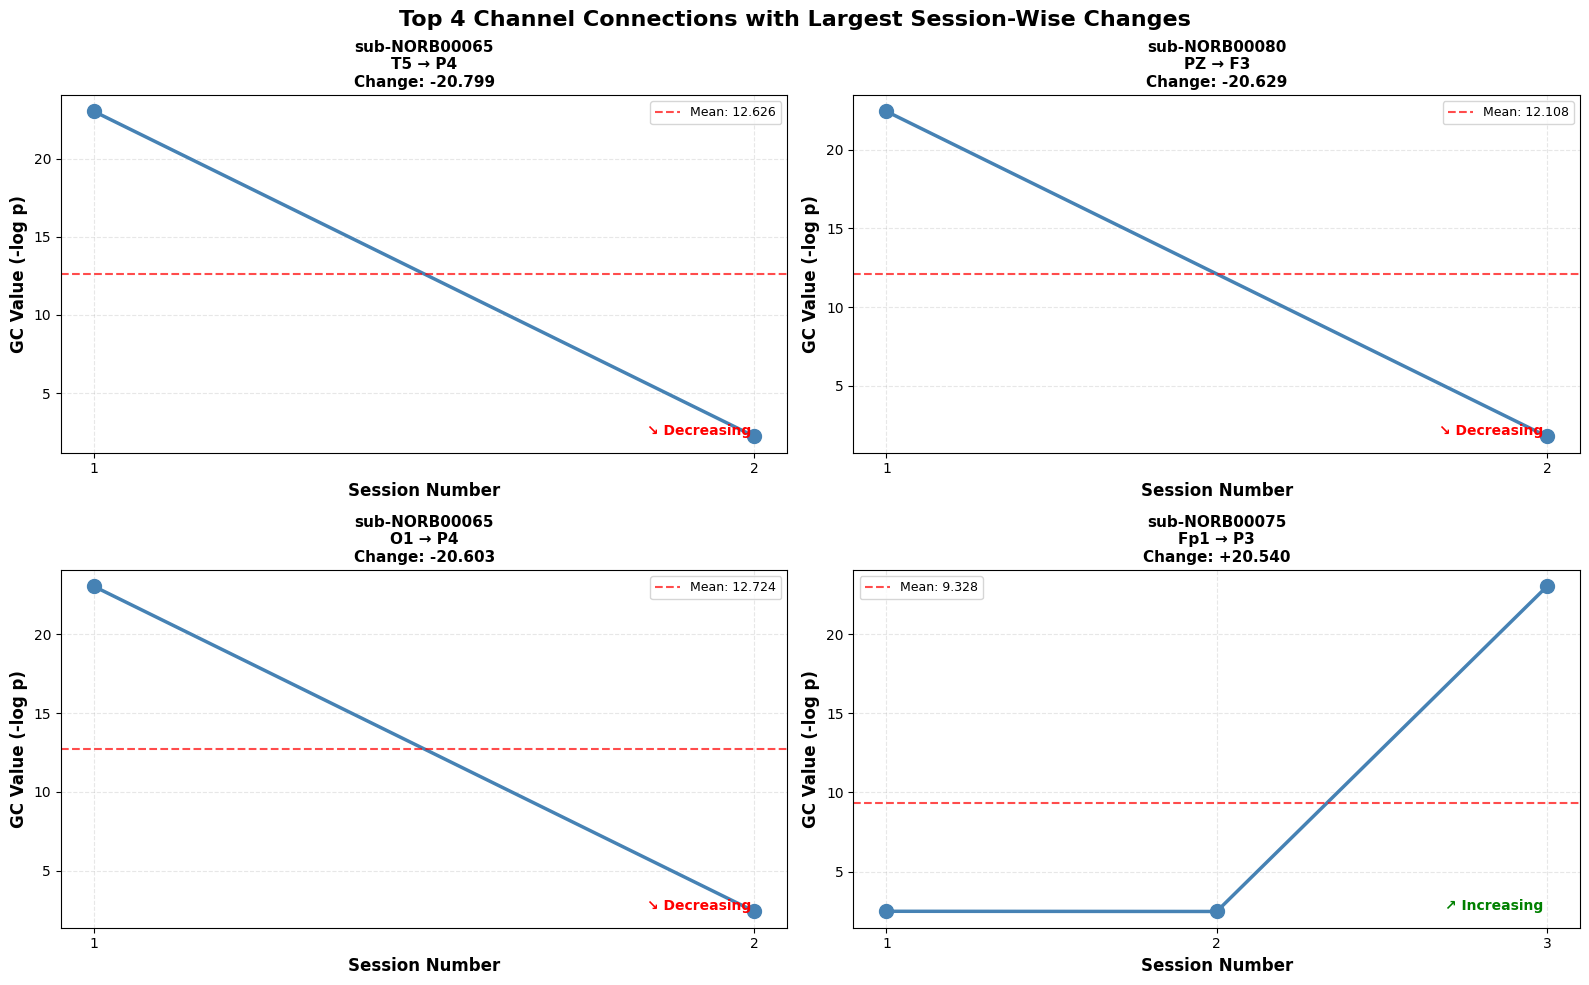

✓ Saved plot to: /home/alookaladdoo/DPCN-Project/results/top_channel_changes.png


In [12]:
# Visualize top changing channel connections
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Top 4 Channel Connections with Largest Session-Wise Changes', 
             fontsize=16, fontweight='bold')

# Get top 4 connections
top_4 = df_connection_changes.head(4)

for ax, (idx, row) in zip(axes.flat, top_4.iterrows()):
    subject_id = row['Subject']
    connection = (row['Source'], row['Target'])
    
    # Get GC values across sessions
    gc_values = channel_analysis[subject_id][connection]
    sessions = range(1, len(gc_values) + 1)
    
    # Plot
    ax.plot(sessions, gc_values, 'o-', linewidth=2.5, markersize=10, color='steelblue')
    ax.axhline(y=np.mean(gc_values), color='red', linestyle='--', linewidth=1.5, 
               alpha=0.7, label=f'Mean: {np.mean(gc_values):.3f}')
    
    # Styling
    ax.set_xlabel('Session Number', fontsize=12, fontweight='bold')
    ax.set_ylabel('GC Value (-log p)', fontsize=12, fontweight='bold')
    ax.set_title(f'{subject_id}\n{row["Connection"]}\nChange: {row["Change"]:+.3f}', 
                fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xticks(sessions)
    ax.legend(loc='best', fontsize=9)
    
    # Add trend arrow
    if row['Change'] > 0:
        ax.text(0.95, 0.05, '↗ Increasing', transform=ax.transAxes, 
                fontsize=10, color='green', fontweight='bold', ha='right')
    else:
        ax.text(0.95, 0.05, '↘ Decreasing', transform=ax.transAxes, 
                fontsize=10, color='red', fontweight='bold', ha='right')

plt.tight_layout()
plt.savefig(output_dir / 'top_channel_changes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved plot to: {output_dir / 'top_channel_changes.png'}")


Plotting detailed analysis for sub-NORB00069...
✓ Saved to: /home/alookaladdoo/DPCN-Project/results/sub-NORB00069_all_connections.png


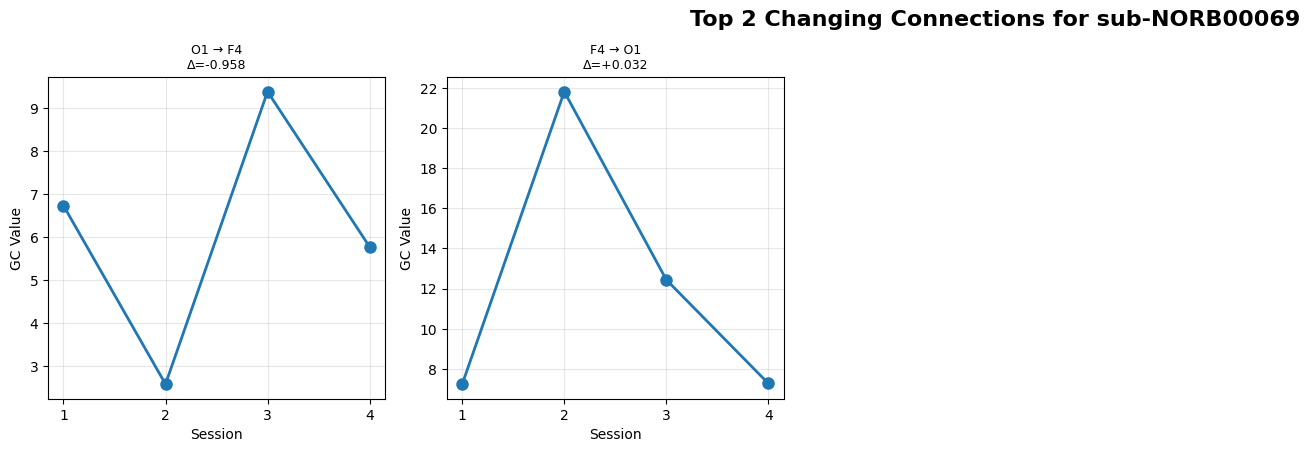

In [13]:
# Visualize all connections for a specific subject
def plot_all_connections_for_subject(subject_id, channel_analysis, session_results, 
                                     save_path=None, top_n=10):
    """
    Plot session-wise changes for top N connections in a subject.
    """
    if subject_id not in channel_analysis:
        print(f"Subject {subject_id} not found in analysis")
        return
    
    connections = channel_analysis[subject_id]
    
    # Calculate changes and sort
    connection_changes = []
    for conn, values in connections.items():
        change = values[-1] - values[0]
        connection_changes.append((conn, values, change, np.std(values)))
    
    # Sort by absolute change
    connection_changes.sort(key=lambda x: abs(x[2]), reverse=True)
    
    # Plot top N
    n_plot = min(top_n, len(connection_changes))
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flat
    
    fig.suptitle(f'Top {n_plot} Changing Connections for {subject_id}', 
                 fontsize=16, fontweight='bold')
    
    for idx in range(n_plot):
        conn, values, change, std = connection_changes[idx]
        ax = axes[idx]
        
        sessions = range(1, len(values) + 1)
        
        # Plot line
        ax.plot(sessions, values, 'o-', linewidth=2, markersize=8)
        
        # Styling
        ax.set_xlabel('Session', fontsize=10)
        ax.set_ylabel('GC Value', fontsize=10)
        ax.set_title(f'{conn[0]} → {conn[1]}\nΔ={change:+.3f}', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(sessions)
    
    # Hide unused subplots
    for idx in range(n_plot, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved to: {save_path}")
    
    plt.show()

# Plot for subject with most sessions
if len(channel_analysis) > 0:
    # Get subject with most sessions
    subject_with_most = max(session_results.keys(), 
                           key=lambda x: len(session_results[x]))
    
    print(f"\nPlotting detailed analysis for {subject_with_most}...")
    plot_all_connections_for_subject(
        subject_with_most, 
        channel_analysis, 
        session_results,
        save_path=output_dir / f'{subject_with_most}_all_connections.png',
        top_n=10
    )

In [14]:
# Summary statistics for channel-wise changes
print("=" * 80)
print("CHANNEL-WISE ANALYSIS SUMMARY")
print("=" * 80)

print(f"\n📊 Overall Channel Statistics:")
print(f"  Total subjects analyzed: {len(channel_analysis)}")
print(f"  Total channel pairs tracked: {sum(len(conns) for conns in channel_analysis.values())}")

print(f"\n📈 Connection Change Statistics:")
print(f"  Mean absolute change: {df_connection_changes['Abs_Change'].mean():.4f}")
print(f"  Max absolute change: {df_connection_changes['Abs_Change'].max():.4f}")
print(f"  Connections increasing: {(df_connection_changes['Change'] > 0).sum()}")
print(f"  Connections decreasing: {(df_connection_changes['Change'] < 0).sum()}")

print(f"\n🔗 Most Commonly Changing Connections:")
# Find most common source and target channels in top 20
top_sources = df_connection_changes.head(20)['Source'].value_counts().head(5)
top_targets = df_connection_changes.head(20)['Target'].value_counts().head(5)

print(f"  Most active source channels:")
for ch, count in top_sources.items():
    print(f"    {ch}: appears in {count} top connections")

print(f"  Most active target channels:")
for ch, count in top_targets.items():
    print(f"    {ch}: appears in {count} top connections")

print(f"\n💾 Output Files:")
print(f"  - channel_wise_changes.csv (detailed changes)")
print(f"  - top_channel_changes.png (visualization)")
print(f"  - {subject_with_most}_all_connections.png (subject-specific)")

print("\n" + "=" * 80)

CHANNEL-WISE ANALYSIS SUMMARY

📊 Overall Channel Statistics:
  Total subjects analyzed: 22
  Total channel pairs tracked: 7184

📈 Connection Change Statistics:
  Mean absolute change: 3.4604
  Max absolute change: 20.7991
  Connections increasing: 2951
  Connections decreasing: 4228

🔗 Most Commonly Changing Connections:
  Most active source channels:
    P4: appears in 3 top connections
    T5: appears in 2 top connections
    O1: appears in 2 top connections
    F4: appears in 2 top connections
    Fp2: appears in 2 top connections
  Most active target channels:
    P3: appears in 8 top connections
    P4: appears in 4 top connections
    F3: appears in 3 top connections
    FZ: appears in 3 top connections
    T6: appears in 1 top connections

💾 Output Files:
  - channel_wise_changes.csv (detailed changes)
  - top_channel_changes.png (visualization)
  - sub-NORB00069_all_connections.png (subject-specific)

